# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Zurich Sabil
- **Email:** zurichsabil@gmail.com
- **ID Dicoding:** CDCC329D6Y0598

## Menentukan Pertanyaan Bisnis

- Berapa selisih rata-rata jumlah peminjaman sepeda antara hari kerja dan hari libur di setiap bulan selama tahun 2012?
- Kategori kondisi cuaca (1–4) mana yang mencatat jumlah peminjaman sepeda paling tinggi pada masing-masing tahun, yaitu 2011 dan 2012?
- Bagaimana perbandingan jumlah peminjaman sepeda tertinggi antara tahun 2011 dan 2012?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Wrangling

### Gathering Data

In [ ]:
hour_df = pd.read_csv('/content/drive/MyDrive/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
day_df = pd.read_csv('/content/drive/MyDrive/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Menampilkan 5 baris pertama dari hour_df, dan day_df

### Assessing Data

In [ ]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Tipe data untuk dteday harusnya menggunakan datetime

In [ ]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Tidak terdapat missing value pada hour_df

In [ ]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


Tidak terdapat duplikat pada hour_df

In [ ]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Tipe data untuk dteday harusnya menggunakan datetime

In [ ]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


Tidak terdapat missing value pada day_df

In [ ]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


Tidak terdapat duplikat pada day_df

In [ ]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Pada kedua dataframe tipe data untuk dteday harusnya menggunakan datetime
- Tidak terdapat missing value pada hour_df dan day_df
- Tidak terdapat duplikasi pada hour_df dan day_df

### Cleaning Data

In [ ]:
new_day_df = day_df[[
    'dteday',
    'yr',
    'mnth',
    'workingday',
    'weathersit',
    'cnt'
]].copy()

new_day_df['dteday'] = pd.to_datetime(new_day_df['dteday'])
new_day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      731 non-null    datetime64[ns]
 1   yr          731 non-null    int64         
 2   mnth        731 non-null    int64         
 3   workingday  731 non-null    int64         
 4   weathersit  731 non-null    int64         
 5   cnt         731 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 34.4 KB


Membuat dataframe baru untuk menjawab pertanyaan 1 dan 2, karena lebih efektif dibandingkan dropping kolom.
Tipe data sudah sesuai karena dteday menggunakan datetime.

In [ ]:
new_hour_df = hour_df[[
    'dteday',
    'yr',
    'hr',
    'cnt'
]].copy()

new_hour_df['dteday'] = pd.to_datetime(new_hour_df['dteday'])
new_hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   dteday  17379 non-null  datetime64[ns]
 1   yr      17379 non-null  int64         
 2   hr      17379 non-null  int64         
 3   cnt     17379 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 543.2 KB


Membuat dataframe baru untuk menjawab pertanyaan 3, karena lebih efektif dibandingkan dropping kolom.
Tipe data sudah sesuai karena dteday menggunakan datetime.

**Insight:**
- Membuat 2 data frame dengan copy() sehingga isinya sesuai saat digunakan
- Mengubah tipe data dteday menjadi datetime

## Exploratory Data Analysis (EDA)

### Explore day_df

In [ ]:
new_day_df.describe(include="all")

,dteday,yr,mnth,workingday,weathersit,cnt
count,731,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2012-01-01 00:00:00,0.500684,6.519836,0.683995,1.395349,4504.348837
min,2011-01-01 00:00:00,0.000000,1.000000,0.000000,1.000000,22.000000
25%,2011-07-02 12:00:00,0.000000,4.000000,0.000000,1.000000,3152.000000
50%,2012-01-01 00:00:00,1.000000,7.000000,1.000000,1.000000,4548.000000
75%,2012-07-01 12:00:00,1.000000,10.000000,1.000000,2.000000,5956.000000
max,2012-12-31 00:00:00,1.000000,12.000000,1.000000,3.000000,8714.000000
std,NaN,0.500342,3.451913,0.465233,0.544894,1937.211452


Jumlah data yang dianalisis sebanyak 731 hari. Rata-rata jumlah peminjaman sepeda (cnt) adalah 4504 dengan nilai minimum 22 dan maksimum 8714. Didapatkan nilai median sebesar 4548 dan standar deviasi sebesar 1937.

In [ ]:
day_2012 = new_day_df[new_day_df['yr'] == 1]

average_bicycles = day_2012.groupby(['mnth', 'workingday'])['cnt'].mean().reset_index()
pivot_average_bicycles = average_bicycles.pivot(index='mnth', columns='workingday', values='cnt')
pivot_average_bicycles.columns = ['Holiday/Weekend', 'Working Day']

print(pivot_average_bicycles)

      Holiday/Weekend  Working Day
mnth                              
1         2712.454545  3345.350000
2         2859.333333  3870.150000
3         4983.222222  5455.727273
4         5720.400000  5851.000000
5         6820.222222  6112.863636
6         7174.777778  6583.666667
7         6059.700000  6810.000000
8         6106.625000  7202.173913
9         7270.909091  7294.368421
10        6436.222222  6405.227273
11        4732.600000  5266.900000
12        3197.181818  4427.200000


Untuk menjawab pertanyaan pertama menggunakan metode groupby() untuk Mengelompokkan data berdasarkan bulan dan working day, lalu menggunakan pivot() untuk perbandingan, didapatkan rata-rata peminjaman per bulan.

In [ ]:
weather_result = day_2012.groupby('weathersit')['cnt'].sum().reset_index()
weather_result = weather_result.sort_values(by='cnt', ascending=False)

print(weather_result)

   weathersit      cnt
0           1  1422885
1           2   613934
2           3    12757


Untuk menjawab pertanyaan kedua menggunakan metode groupby() untuk mengelompokkan data berdasarkan cuaca, lalu ditotal. Sehingga didapatkan total peminjaman sepeda berdasarkan cuaca.

### Explore hours_df

In [ ]:
hour_2011 = new_hour_df[new_hour_df['yr'] == 0]
hour_result_2011 = hour_2011.groupby('hr')['cnt'].sum().reset_index()
hour_result_2011 = hour_result_2011.sort_values(by='hr', ascending=True)

hour_2012 = new_hour_df[new_hour_df['yr'] == 1]
hour_result_2012 = hour_2012.groupby('hr')['cnt'].sum().reset_index()
hour_result_2012 = hour_result_2012.sort_values(by='hr', ascending=True)

hour_result_2011.rename(columns={'cnt': '2011'}, inplace=True)
hour_result_2012.rename(columns={'cnt': '2012'}, inplace=True)

hour_compare = pd.merge(hour_result_2011, hour_result_2012, on='hr')

print(hour_compare)

    hr    2011    2012
0    0   15540   23590
1    1    9558   14606
2    2    6661    9691
3    3    3441    4733
4    4    1817    2611
5    5    5157    9104
6    6   20801   34331
7    7   56930   97241
8    8   95467  165534
9    9   59486   99952
10  10   47511   78746
11  11   56598   94722
12  12   69198  115216
13  13   69339  115580
14  14   66482  109170
15  15   68590  114559
16  16   85622  142126
17  17  127632  209228
18  18  116985  192787
19  19   85802  140987
20  20   62818  101732
21  21   48875   76570
22  22   37677   57935
23  23   25116   38825


Untuk menjawab pertanyaan ketiga, menggunakan metode groupby() untuk mendapatkan jam, lalu ditotal. Lalu pada variabel hour_compare menggunakan merge() untuk compare tahun 2011 dan 2012.

**Insight:**
- Peminjaman sepeda cenderung lebih tinggi pada hari kerja, puncak terjadi di bulan September.
- Cuaca cerah mendominasi penggunaan sepeda dan hujan sangat mengurangi minat bersepeda.
- Mayoritas peminjaman sepeda dilakukan pada pagi hari yaitu pukul 08.00 dan sore hari pada pukul 15.00 dan pada tahun 2012 terjadi peningkatan pada peminjaman sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

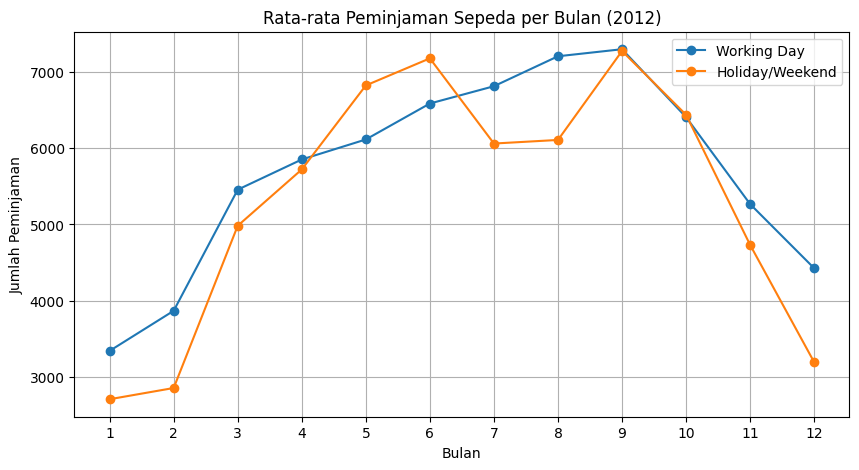

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(pivot_average_bicycles.index,
         pivot_average_bicycles['Working Day'],
         marker='o', label='Working Day')

plt.plot(pivot_average_bicycles.index,
         pivot_average_bicycles['Holiday/Weekend'],
         marker='o', label='Holiday/Weekend')

plt.title('Rata-rata Peminjaman Sepeda per Bulan (2012)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Peminjaman')
plt.xticks(pivot_average_bicycles.index)
plt.legend()
plt.grid(True)

plt.show()

Didapatkan puncak terjadi di bulan September.

### Pertanyaan 2:

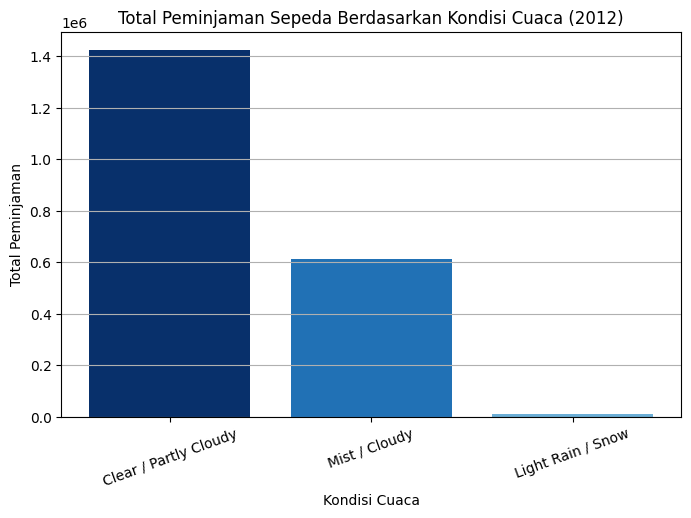

In [ ]:
weather_labels = {
    1: 'Clear / Partly Cloudy',
    2: 'Mist / Cloudy',
    3: 'Light Rain / Snow'
}

weather_filtered = weather_result[weather_result['weathersit'].isin([1,2,3])]
weather_filtered['label'] = weather_filtered['weathersit'].map(weather_labels)

colors = ['#08306b', '#2171b5', '#6baed6']

plt.figure(figsize=(8,5))
plt.bar(weather_filtered['label'], weather_filtered['cnt'], color=colors)

plt.title('Total Peminjaman Sepeda Berdasarkan Kondisi Cuaca (2012)')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Total Peminjaman')

plt.xticks(rotation=20)
plt.grid(axis='y')

plt.show()

Didapatkan cuaca cerah mendominasi penggunaan sepeda.

###Pertanyaan 3:

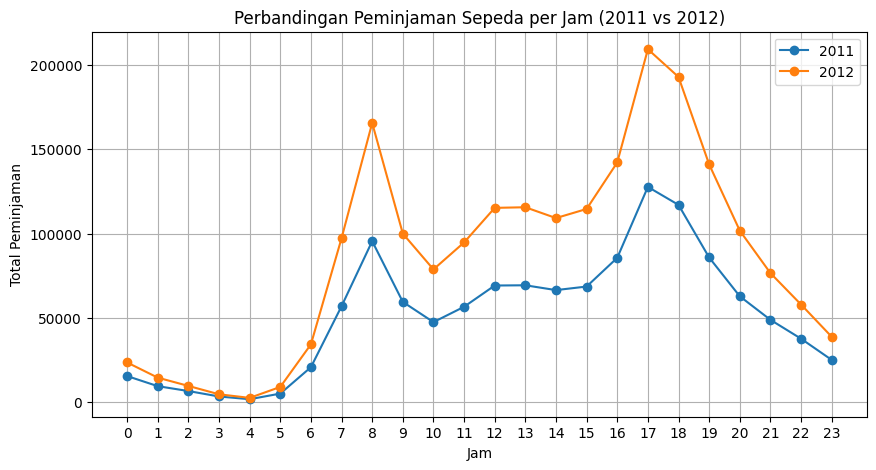

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(hour_result_2011['hr'], hour_result_2011['2011'], marker='o', label='2011')
plt.plot(hour_result_2012['hr'], hour_result_2012['2012'], marker='o', label='2012')

plt.title('Perbandingan Peminjaman Sepeda per Jam (2011 vs 2012)')
plt.xlabel('Jam')
plt.ylabel('Total Peminjaman')
plt.xticks(range(0,24))
plt.legend()
plt.grid(True)

plt.show()

Didapatkan peminjaman sepeda dilakukan pada pagi hari yaitu pukul 08.00 dan sore hari pada pukul 15.00

**Insight:**
- Peminjaman lebih tinggi saat hari kerja, dengan puncak di bulan September.
- Cuaca cerah meningkatkan penggunaan, sedangkan hujan menurunkannya drastis.
- Puncak terjadi pukul 08.00 dan sore hari, serta terjadi peningkatan pada tahun 2012.

## Analisis Lanjutan Clustering

  time_group      cnt
0      Malam   768585
1       Pagi   644003
2      Siang   822562
3       Sore  1057529


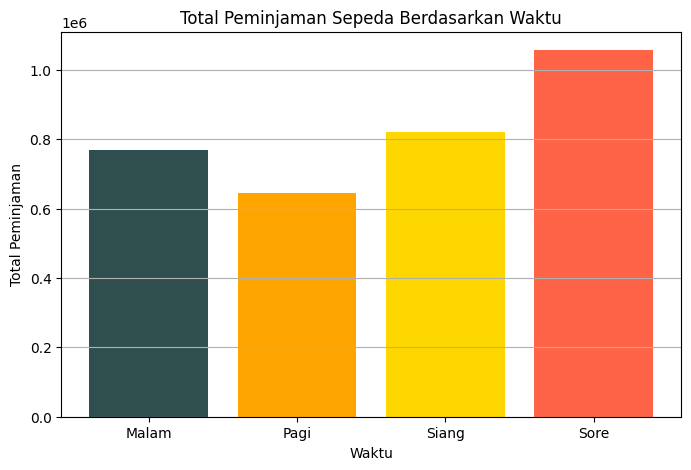

In [ ]:
def time_category(hour):
    if 5 <= hour < 10:
        return 'Pagi'
    elif 10 <= hour < 15:
        return 'Siang'
    elif 15 <= hour < 19:
        return 'Sore'
    else:
        return 'Malam'

new_hour_df['time_group'] = new_hour_df['hr'].apply(time_category)

time_group_result = new_hour_df.groupby('time_group')['cnt'].sum().reset_index()
print(time_group_result)

color_map = {
    'Pagi': '#FFA500',
    'Siang': '#FFD700',
    'Sore': '#FF6347',
    'Malam': '#2F4F4F'
}

colors = [color_map[t] for t in time_group_result['time_group']]

plt.figure(figsize=(8,5))
plt.bar(time_group_result['time_group'], time_group_result['cnt'], color=colors)

plt.title('Total Peminjaman Sepeda Berdasarkan Waktu')
plt.xlabel('Waktu')
plt.ylabel('Total Peminjaman')

plt.grid(axis='y')
plt.show()

Dilakukan clustering Manual Grouping menjadi Malam, Pagi, Siang dan Sore untuk mengetahui tingkat peminjaman sepeda paling tinggi.

## Conclusion

Pertanyaan:
- Bagaimana selisih rata-rata peminjaman sepeda antara hari kerja dan hari libur pada tiap bulan di tahun 2012?
- Dari kategori cuaca (1–4), kondisi mana yang mencatat jumlah peminjaman sepeda paling tinggi pada masing-masing tahun (2011 dan 2012)?
- Seperti apa perbandingan jumlah peminjaman sepeda tertinggi antara tahun 2011 dan 2012?


Kesimpulan:
- Aktivitas peminjaman sepeda cenderung lebih tinggi pada hari kerja, dengan titik tertinggi terjadi di bulan September.
- Kondisi cuaca cerah menjadi faktor utama meningkatnya penggunaan, sementara hujan secara signifikan menurunkan jumlah peminjaman.
- Puncak peminjaman terjadi pada pukul 08.00 dan sore hari, serta mengalami peningkatan pada tahun 2012 dibandingkan tahun sebelumnya.



In [ ]:
new_hour_df.to_csv('new_hour_df.csv', index=False)
new_day_df.to_csv('new_day_df.csv', index=False)
from google.colab import files
files.download('new_hour_df.csv')
files.download('new_day_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>